# Hidden Markov Models from Scratch 🎭

## 🎭 Theoretical Background
Hidden Markov Models are statistical models where the system being modeled is assumed to be a Markov process with unobserved (hidden) states.
- **Forward Algorithm**: Computes the probability of an observation sequence.
- **Viterbi Algorithm**: Finds the most likely sequence of hidden states.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# States: Rain (0), Sunny (1)
# Observations: Umbrella (0), No Umbrella (1)
start_prob = np.array([0.5, 0.5])
trans_prob = np.array([[0.7, 0.3], [0.4, 0.6]]) # R->R, R->S; S->R, S->S
emit_prob = np.array([[0.9, 0.1], [0.2, 0.8]])  # R: U, NoU; S: U, NoU

obs_seq = np.array([0, 0, 1]) # Umbrella, Umbrella, No Umbrella

def forward(obs, start, trans, emit):
    """Forward Algorithm: computes P(observation sequence) by summing,
    at each step, over all ways to reach each state (unlike Viterbi,
    which keeps only the single best path)."""
    N = trans.shape[0]
    T = len(obs)
    alpha = np.zeros((T, N))

    alpha[0] = start * emit[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = np.sum(alpha[t-1] * trans[:, j]) * emit[j, obs[t]]

    obs_seq_prob = np.sum(alpha[T-1])
    return alpha, obs_seq_prob

alpha, obs_seq_prob = forward(obs_seq, start_prob, trans_prob, emit_prob)
print(f"P(observation sequence) = {obs_seq_prob:.6f}")

def viterbi(obs, start, trans, emit):
    N = trans.shape[0]
    T = len(obs)
    delta = np.zeros((T, N))
    phi = np.zeros((T, N), dtype=int)
    
    delta[0] = start * emit[:, obs[0]]
    
    for t in range(1, T):
        for j in range(N):
            delta[t, j] = np.max(delta[t-1] * trans[:, j]) * emit[j, obs[t]]
            phi[t, j] = np.argmax(delta[t-1] * trans[:, j])
            
    states = np.zeros(T, dtype=int)
    states[T-1] = np.argmax(delta[T-1])
    for t in range(T-2, -1, -1):
        states[t] = phi[t+1, states[t+1]]
    return states

inferred_states = viterbi(obs_seq, start_prob, trans_prob, emit_prob)
print(f"Sequence of states: {['Rain' if s == 0 else 'Sunny' for s in inferred_states]}")


### 📊 Visualization: State Probabilities

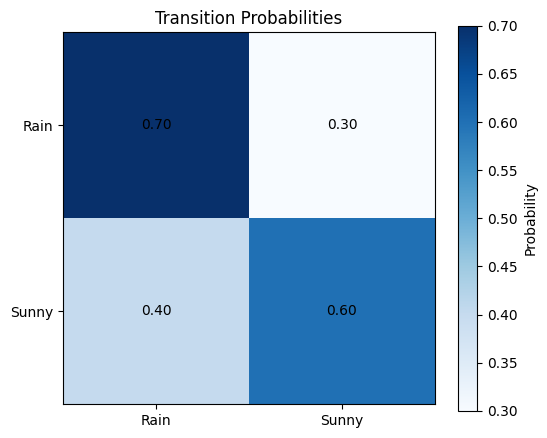

In [3]:

# Visualizing the transition matrix
plt.figure(figsize=(6, 5))
plt.imshow(trans_prob, cmap='Blues')
plt.xticks([0, 1], ['Rain', 'Sunny'])
plt.yticks([0, 1], ['Rain', 'Sunny'])
plt.colorbar(label='Probability')
plt.title('Transition Probabilities')
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{trans_prob[i, j]:.2f}', ha='center', va='center')
plt.show()
